In [2]:
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shapereader
import pyreadr
import matplotlib.ticker as mticker

#### ERF

In [ ]:
result = pyreadr.read_r("C:\\Users\\liprandicn\\Downloads\\Fig2_20Nov2025.RData")
result.keys()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.flatten()

groups = ['40', '55', '70', '85']
diseases = ['ncrc', 'rsp', 'cvd', 'all']

colors = plt.cm.tab10(range(len(groups)))  # un color por grupo

for i, disease in enumerate(diseases):
    ax = axes[i]

    for j, group in enumerate(groups):
        color = colors[j]

        x = result[disease]['Percentile']
        y = result[disease][f'{disease}_{group}_rr']
        low = result[disease][f'{disease}_{group}_rr_low']
        high = result[disease][f'{disease}_{group}_rr_high']

        # línea central
        ax.plot(x, y, label=f'Age {group}', color=color)

        # banda sombreada
        ax.fill_between(x, low, high, color=color, alpha=0.25)

    ax.set_title(disease.upper())
    ax.legend()
    ax.set_xlabel('Percentile')
    ax.set_ylabel('Relative Risk')
    ax.set_ylim(0.9,1.65)
    ax.axhline(1.0, linestyle='--', color='grey')

plt.tight_layout()
plt.show()

#### Temperature Percentiles

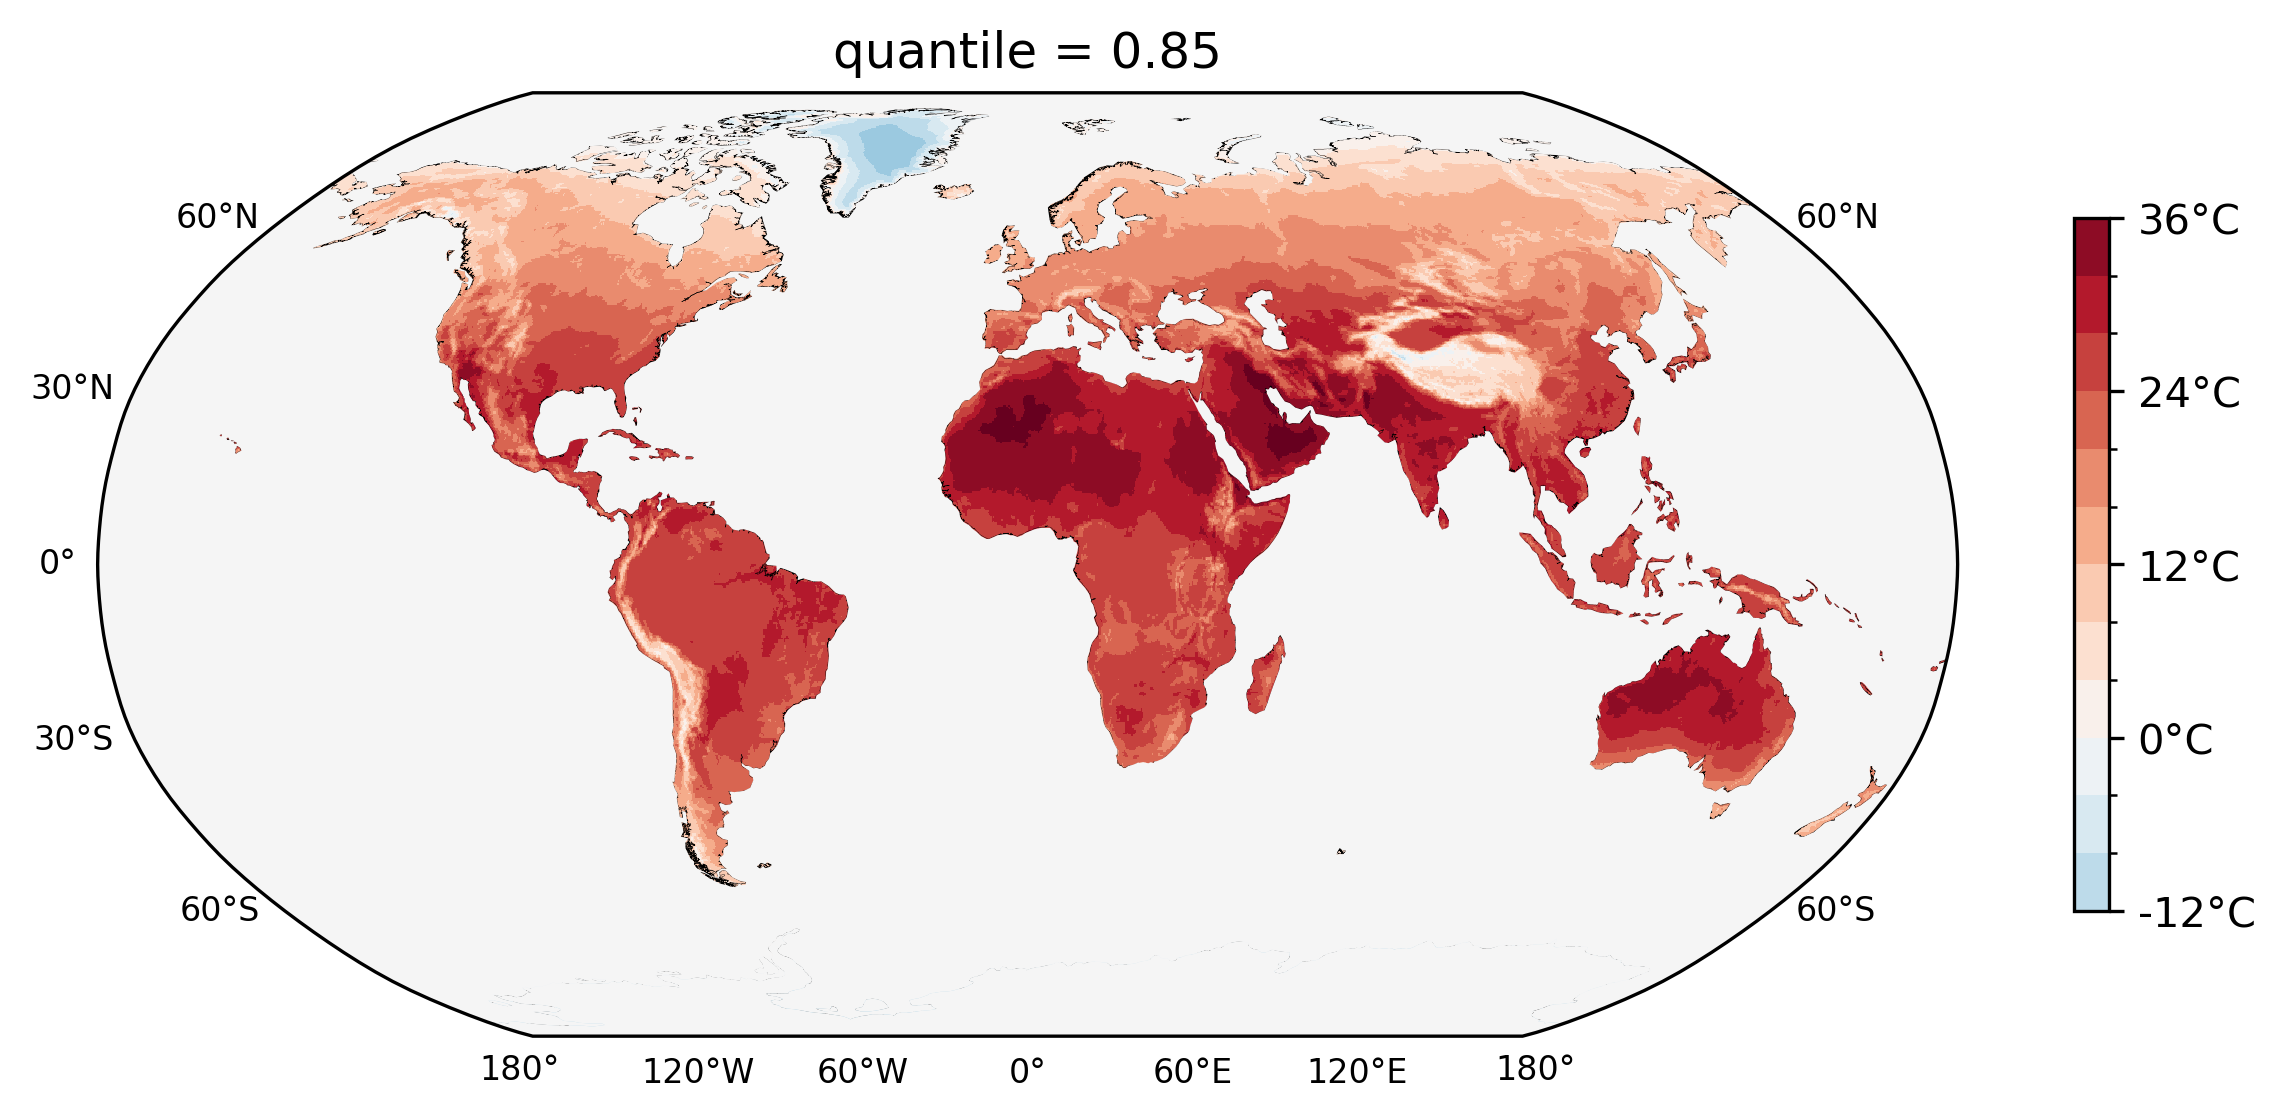

In [7]:
# Map of optimal temperatures (84th percentile of daily maximum temperatures) from ERA5 reanalysis for 1980-2010 period.

wdir = "X:\\user\\liprandicn\\mt-comparison\\scovronick2024/data/"
percentiles = xr.open_dataset(wdir+"Percentiles_Maps/ERA5_Tmean_Percentiles_1980-2010.nc")
ot = percentiles.sel(quantile=0.85, method="nearest")

fig = plt.figure(figsize=(10,5), dpi=300)
ax = fig.add_subplot(111, projection=ccrs.Robinson(central_longitude=0), frameon=True)
ax.coastlines(resolution='10m', lw = 0.1)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0, color='lightgray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}
im = ot.t2m.plot(ax=ax, 
                transform=ccrs.PlateCarree(), 
                cmap='RdBu_r', 
                add_colorbar=False,
                levels=21, 
                vmin=-40, 
                vmax=40)
ax.add_feature(cfeature.OCEAN, facecolor='whitesmoke', zorder=2)

# Manually set colorbar limits
cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.6, pad=0.05, aspect=20)
# cbar.set_label(r'Daily maximum temperature', fontsize=8)
cbar.ax.set_ylim(-12, 36) 
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d°C'))

# Remove Antarctica 
land_shp = shapereader.natural_earth(resolution='110m', category='physical', name='land')
land_geoms = shapereader.Reader(land_shp).geometries()
for land in land_geoms:
    if land.bounds[1] < -60:
        ax.add_geometries([land], ccrs.PlateCarree(), 
                          facecolor='whitesmoke', 
                          edgecolor='none', 
                          zorder=2)